# HealthConnect Analytical Testing & Validation

## 1. Testing Objective

The objective of this testing stage is to independently validate the key
analytical outputs produced during Weeks 5 and 6.

The testing will focus on:

- Validating the accuracy of the core KPIs.
- Reproducing key no-show findings from the underlying dataset.
- Checking whether important findings remain consistent across relevant
  segments.
- Validating the higher-risk appointment segments identified during Week 6.
- Testing reminder coverage and reminder effectiveness findings.
- Reviewing selected visualisations for consistency with the validated results.
- Identifying any analytical inconsistencies or weaknesses that require
  refinement.
- Re-testing outputs after any refinement.

The results will be used to determine whether the key analytical outputs are
sufficiently reliable for continued integration into the wider HealthConnect
solution.

## 2. Testing Approach

The testing will be conducted using the original HealthConnect appointment
dataset as the source of truth.

Key outputs from the Week 5 and Week 6 analysis will be independently
recalculated and compared with their previously reported results.

The testing process will follow:

**Recalculate → Compare → Validate → Refine where necessary → Re-test**

The main testing areas are:

1. **KPI Validation**
   - No-Show Rate
   - Reminder Effectiveness Rate
   - Reminder Non-send Rate
   - Average Waiting Time

2. **Analytical Findings Validation**
   - Booking lead time and no-show behaviour.
   - Previous no-show history and current outcomes.
   - Higher-risk appointment segments.
   - Reminder coverage across booking lead-time groups.
   - Reminder effectiveness within higher-risk segments.

3. **Visualisation Validation**
   - Check whether selected visualisations accurately represent the underlying
     calculations.
   - Review labels, groupings, and interpretation for clarity.

4. **Cross-Track Validation**
   - Review the relationship between the validated analytical findings and
     the Data Science no-show prediction model.

Testing results will be documented using expected results, actual results,
validation status, identified issues, actions taken, and retest results where
applicable.

## 3. Imports and Dataset Setup

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [2]:
# dataset
df = pd.read_csv("data/HealthConnect_Appointment_Data.csv")

df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


### Data transformations

In [3]:
# Convert date fields
df["booking_date"] = pd.to_datetime(df["booking_date"])
df["appointment_date"] = pd.to_datetime(df["appointment_date"])

In [5]:
# Missing reminder channel indicates that no reminder was sent
df["reminder_channel"] = df["reminder_channel"].fillna("No reminder")
df["reminder_channel"].value_counts()

reminder_channel
SMS            2000
No reminder    1366
WhatsApp       1101
Email           533
Name: count, dtype: int64

## 4. KPI Validation

The core KPIs established during the earlier analysis are independently
recalculated from the underlying dataset and compared with their previously
reported values.

### 4.1 No-Show Rate

In [7]:
# Calculate No-Show Rate independently
total_appointments = len(df)

no_show_appointments = (
    df["appointment_outcome"] == "No-Show"
).sum()

validated_no_show_rate = (
    no_show_appointments / total_appointments
) * 100

print(f"Total appointments: {total_appointments:,}")
print(f"No-show appointments: {no_show_appointments:,}")
print(f"Validated No-Show Rate: {validated_no_show_rate:.2f}%")

Total appointments: 5,000
No-show appointments: 2,423
Validated No-Show Rate: 48.46%


Original KPI:

In [8]:
# Compared against the previously reported KPI
reported_no_show_rate = 48.46

difference = abs(
    validated_no_show_rate - reported_no_show_rate
)

print(f"Previously reported: {reported_no_show_rate:.2f}%")
print(f"Validated: {validated_no_show_rate:.2f}%")
print(f"Difference: {difference:.2f} percentage points")

Previously reported: 48.46%
Validated: 48.46%
Difference: 0.00 percentage points


> **Validation Result:** The independently calculated No-Show Rate matches the
previously reported value of **48.46%**, with a difference of **0.00 percentage
points**. The KPI calculation is therefore validated.

### 4.2 Reminder Non-send Rate

In [9]:
# Calculate Reminder Non-send Rate independently
no_reminder_appointments = (
    df["reminder_channel"] == "No reminder"
).sum()

validated_non_send_rate = (
    no_reminder_appointments / total_appointments
) * 100

print(f"Appointments without reminder: {no_reminder_appointments:,}")
print(f"Validated Reminder Non-send Rate: {validated_non_send_rate:.2f}%")

Appointments without reminder: 1,366
Validated Reminder Non-send Rate: 27.32%


In [11]:
# original KPI
reported_non_send_rate = 27.32

difference = abs(
    validated_non_send_rate - reported_non_send_rate
)

print(f"Previously reported: {reported_non_send_rate:.2f}%")
print(f"Validated: {validated_non_send_rate:.2f}%")
print(f"Difference: {difference:.2f} percentage points")

Previously reported: 27.32%
Validated: 27.32%
Difference: 0.00 percentage points


> **Validation Result:** The independently calculated Reminder Non-send Rate
matches the previously reported value of **27.32%**, confirming the KPI
calculation against the underlying dataset.

### 4.3 Reminder Effectiveness Rate

In [12]:
# Calculate attendance rate by reminder channel
validated_reminder_effectiveness = (
    df.groupby("reminder_channel")["appointment_outcome"]
    .apply(lambda x: (x == "Attended").mean() * 100)
    .reset_index(name="attendance_rate")
)

validated_reminder_effectiveness["attendance_rate"] = (
    validated_reminder_effectiveness["attendance_rate"].round(2)
)

validated_reminder_effectiveness

,reminder_channel,attendance_rate
0,Email,46.53
1,No reminder,42.68
2,SMS,49.60
3,WhatsApp,44.60


In [13]:
# Check the underlying outcome counts
reminder_outcome_counts = pd.crosstab(
    df["reminder_channel"],
    df["appointment_outcome"]
)

reminder_outcome_counts

appointment_outcome,Attended,Cancelled,No-Show
reminder_channel,,,
Email,248,27,258
No reminder,583,81,702
SMS,992,93,915
WhatsApp,491,62,548


> **Validation Result:** The independently calculated attendance rates across
reminder channels match the previously reported values. The underlying
appointment counts also reproduce the original results, confirming that the
Reminder Effectiveness Rate calculation is consistent with the dataset.

### 4.4 Average Waiting Time 

In [14]:
# Calculate Average Waiting Time independently
validated_avg_waiting_time = (
    df["waiting_time_minutes"].mean()
)

print(
    f"Validated Average Waiting Time: "
    f"{validated_avg_waiting_time:.2f} minutes"
)

Validated Average Waiting Time: 24.19 minutes


In [15]:
# Comparison with original value
reported_avg_waiting_time =  24.19

difference = abs(
    validated_avg_waiting_time - reported_avg_waiting_time
)

print(f"Previously reported: {reported_avg_waiting_time:.2f} minutes")
print(f"Validated: {validated_avg_waiting_time:.2f} minutes")
print(f"Difference: {difference:.2f} minutes")

Previously reported: 24.19 minutes
Validated: 24.19 minutes
Difference: 0.00 minutes


> **Validation Result:** The independently calculated Average Waiting Time
matches the previously reported KPI, confirming that the calculation is
consistent with the underlying dataset.

### 4.5 KPI Validation Summary

| KPI                         | Previously Reported |           Validated | Difference | Status |
| --------------------------- | ------------------: | ------------------: | ---------: | ------ |
| No-Show Rate                |              48.46% |              48.46% |    0.00 pp | Pass   |
| Reminder Non-send Rate      |              27.32% |              27.32% |    0.00 pp | Pass   |
| Reminder Effectiveness Rate | Channel-level rates | Channel-level rates |    0.00 pp | Pass   |
| Average Waiting Time        |        24.19 mins |          24.19 mins |       0.00 | Pass   |

## 5. Analytical Findings Validation

### 5.1 Booking Lead Time and No-Show Behaviour

In [16]:
# booking lead group setup
lead_time_bins = [-1, 2, 7, 14, 30, float("inf")]

lead_time_labels = [
    "0–2 days",
    "3–7 days",
    "8–14 days",
    "15–30 days",
    "31+ days"
]

df["booking_lead_group_test"] = pd.cut(
    df["booking_lead_days"],
    bins=lead_time_bins,
    labels=lead_time_labels
)

In [18]:
# Lead time validation
lead_time_validation = (
    df.groupby(
        "booking_lead_group_test",
        observed=True
    )["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .reset_index(name="no_show_rate")
)

lead_time_validation["no_show_rate"] = (
    lead_time_validation["no_show_rate"].round(2)
)

# appointment counts
lead_time_counts = (
    df["booking_lead_group_test"]
    .value_counts()
    .sort_index()
)

lead_time_validation = lead_time_validation.merge(
    lead_time_counts.rename("appointment_count"),
    left_on="booking_lead_group_test",
    right_index=True
)

lead_time_validation

,booking_lead_group_test,no_show_rate,appointment_count
0,0–2 days,24.18,244
1,3–7 days,30.05,396
2,8–14 days,33.55,602
3,15–30 days,43.21,1333
4,31+ days,60.49,2425


#### 5.1.1 Comparison with Week 6 finding

In [21]:
no_show_rates = lead_time_validation["no_show_rate"].tolist()

is_monotonic = all(
    earlier < later
    for earlier, later in zip(no_show_rates, no_show_rates[1:])
)

print(f"No-show rates increase consistently: {is_monotonic}")


No-show rates increase consistently: True


#### 5.1.2 Statistical Validation

In [ ]:
# Booking lead time x appointment outcome
from scipy.stats import chi2_contingency

lead_time_outcome_counts = pd.crosstab(
    df["booking_lead_group_test"],
    df["appointment_outcome"]
)

chi2, p_value, dof, expected = chi2_contingency(
    lead_time_outcome_counts
)

n = lead_time_outcome_counts.to_numpy().sum()
min_dimension = min(lead_time_outcome_counts.shape) - 1

cramers_v = np.sqrt(
    chi2 / (n * min_dimension)
)


print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.6f}")
print(f"Cramér's V: {cramers_v:.3f}")

Chi-square statistic: 341.12
Degrees of freedom: 8
p-value: 0.000000
Cramér's V: 0.185


**Validation Result:** The independently reproduced Chi-square test and
Cramér's V exactly match the Week 6 results (χ² = 341.12, df = 8,
p < 0.001, Cramér's V = 0.185). The statistical finding is therefore
validated against the underlying dataset.

**Status:** Pass

### 5.2 Previous No-Show Behaviour

In [ ]:

previous_no_show_outcomes = pd.crosstab(
    df["previous_no_shows"],
    df["appointment_outcome"]
)

chi2, p_value, dof, expected = chi2_contingency(
    previous_no_show_outcomes
)

n = previous_no_show_outcomes.to_numpy().sum()
min_dimension = min(previous_no_show_outcomes.shape) - 1

cramers_v = np.sqrt(
    chi2 / (n * min_dimension)
)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.6f}")
print(f"Previous no-shows — Cramér's V: {cramers_v:.3f}")

Chi-square statistic: 83.38
Degrees of freedom: 10
p-value: 0.000000
Previous no-shows — Cramér's V: 0.091


**Validation Result:** The independently reproduced Chi-square test and
Cramér's V exactly match the Week 6 results (χ² = 83.38, df = 10,
p < 0.001, Cramér's V = 0.091). The statistical finding is therefore
validated against the underlying dataset.

**Status:** Pass

### 5.3 Higher-Risk Segments

Week 6 identified several combinations of previous no-show history and booking lead time with relatively high observed no-show rates. These segments were validated against the underlying dataset to confirm that the reported rates and appointment volumes were reproducible.

In [25]:
high_risk_validation = (
    df.groupby(
        ["previous_no_shows", "booking_lead_group_test"],
        observed=True
    )
    .agg(
        appointments=("appointment_id", "count"),
        no_shows=("appointment_outcome", lambda x: (x == "No-Show").sum())
    )
    .reset_index()
)

high_risk_validation["no_show_rate"] = (
    high_risk_validation["no_shows"]
    / high_risk_validation["appointments"]
    * 100
)

high_risk_validation

,previous_no_shows,booking_lead_group_test,appointments,no_shows,no_show_rate
0,0,0–2 days,146,26,17.808219
1,0,3–7 days,226,55,24.336283
2,0,8–14 days,376,119,31.648936
3,0,15–30 days,763,293,38.401048
4,0,31+ days,1410,778,55.177305
5,1,0–2 days,69,21,30.434783
6,1,3–7 days,121,42,34.710744
7,1,8–14 days,157,50,31.847134
8,1,15–30 days,419,196,46.778043
9,1,31+ days,782,519,66.368286


In [26]:
selected_segments = high_risk_validation[
    (
        (high_risk_validation["previous_no_shows"] == 2) &
        (high_risk_validation["booking_lead_group_test"] == "31+ days")
    )
    |
    (
        (high_risk_validation["previous_no_shows"] == 1) &
        (high_risk_validation["booking_lead_group_test"] == "31+ days")
    )
    |
    (
        (high_risk_validation["previous_no_shows"] == 0) &
        (high_risk_validation["booking_lead_group_test"] == "31+ days")
    )
    |
    (
        (high_risk_validation["previous_no_shows"] == 2) &
        (high_risk_validation["booking_lead_group_test"] == "15–30 days")
    )
    |
    (
        (high_risk_validation["previous_no_shows"] == 1) &
        (high_risk_validation["booking_lead_group_test"] == "15–30 days")
    )
].copy()

selected_segments

,previous_no_shows,booking_lead_group_test,appointments,no_shows,no_show_rate
4,0,31+ days,1410,778,55.177305
8,1,15–30 days,419,196,46.778043
9,1,31+ days,782,519,66.368286
13,2,15–30 days,125,66,52.800000
14,2,31+ days,191,136,71.204188


> **Validation Result:** The independently reproduced appointment counts and no-show rates for the selected higher-risk segments match the Week 6 analysis.

**Status:** Pass

### 5.4 Reminder Coverage

In [27]:
reminder_coverage_validation = (
    df.groupby("booking_lead_group_test", observed=True)["reminder_channel"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percentage")
    .reset_index()
)

reminder_coverage_validation

,booking_lead_group_test,reminder_channel,percentage
0,0–2 days,SMS,41.393443
1,0–2 days,No reminder,28.278689
2,0–2 days,WhatsApp,18.032787
3,0–2 days,Email,12.295082
4,3–7 days,SMS,41.666667
5,3–7 days,No reminder,24.747475
6,3–7 days,WhatsApp,19.696970
7,3–7 days,Email,13.888889
8,8–14 days,SMS,41.528239
9,8–14 days,No reminder,26.744186


In [28]:
no_reminder_by_lead_time = (
    df.assign(
        no_reminder=df["reminder_channel"] == "No reminder"
    )
    .groupby("booking_lead_group_test", observed=True)["no_reminder"]
    .mean()
    .mul(100)
    .reset_index(name="no_reminder_rate")
)

no_reminder_by_lead_time

,booking_lead_group_test,no_reminder_rate
0,0–2 days,28.278689
1,3–7 days,24.747475
2,8–14 days,26.744186
3,15–30 days,28.357089
4,31+ days,27.216495


**Validation Result:** Reminder coverage was independently reproduced across booking lead-time groups. The no-reminder rate ranged from 24.75% to 28.36%, indicating relatively consistent coverage across the groups. The 31+ day group had a no-reminder rate of 27.22%, which does not indicate substantially lower reminder coverage than the other groups.

**Status:** Pass

### 5.5 Reminder Effectiveness

In [29]:
reminder_effectiveness_validation = (
    pd.crosstab(
        df["reminder_channel"],
        df["appointment_outcome"],
        normalize="index"
    )
    .mul(100)
    .reset_index()
)

reminder_effectiveness_validation

appointment_outcome,reminder_channel,Attended,Cancelled,No-Show
0,Email,46.529081,5.065666,48.405253
1,No reminder,42.679356,5.929722,51.390922
2,SMS,49.600000,4.650000,45.750000
3,WhatsApp,44.595822,5.631244,49.772934


In [30]:
attendance_by_reminder = (
    df.assign(
        attended=df["appointment_outcome"] == "Attended"
    )
    .groupby("reminder_channel")["attended"]
    .mean()
    .mul(100)
    .reset_index(name="attendance_rate")
)

attendance_by_reminder

,reminder_channel,attendance_rate
0,Email,46.529081
1,No reminder,42.679356
2,SMS,49.600000
3,WhatsApp,44.595822


In [34]:
# high-risk subset
high_risk_mask = (
    (
        (df["previous_no_shows"] == 2) &
        (df["booking_lead_group_test"] == "31+ days")
    )
    |
    (
        (df["previous_no_shows"] == 1) &
        (df["booking_lead_group_test"] == "31+ days")
    )
    |
    (
        (df["previous_no_shows"] == 0) &
        (df["booking_lead_group_test"] == "31+ days")
    )
    |
    (
        (df["previous_no_shows"] == 2) &
        (df["booking_lead_group_test"] == "15–30 days")
    )
    |
    (
        (df["previous_no_shows"] == 1) &
        (df["booking_lead_group_test"] == "15–30 days")
    )
)

high_risk_df = df[high_risk_mask].copy()

high_risk_reminder_validation = (
    pd.crosstab(
        high_risk_df["reminder_channel"],
        high_risk_df["appointment_outcome"],
        normalize="index"
    )
    .mul(100)
    .reset_index()
)

high_risk_reminder_validation


appointment_outcome,reminder_channel,Attended,Cancelled,No-Show
0,Email,37.864078,3.559871,58.576052
1,No reminder,33.415536,5.548705,61.035758
2,SMS,39.982348,4.766108,55.251545
3,WhatsApp,35.905045,5.786350,58.308605


In [35]:
#group size validation
high_risk_df["reminder_channel"].value_counts()

reminder_channel
SMS            1133
No reminder     811
WhatsApp        674
Email           309
Name: count, dtype: int64

**Validation Result:** Reminder effectiveness was independently reproduced at both the overall dataset level and within the higher-risk segments identified in Week 6. The observed channel-level attendance and no-show rates matched the original analysis.

Within the higher-risk segments, appointments with no recorded reminder continued to have the highest observed no-show rate, while differences between reminder channels remained relatively modest.

**Status:** Pass

## 6. Visualisation Validation

### 6.1 Appointment Outcomes by Booking Lead Time

In [50]:
outcome_by_lead_time = (
    pd.crosstab(
        df["booking_lead_group_test"],
        df["appointment_outcome"],
        normalize="index"
    )
    .mul(100)
    .reset_index()
)

# confirm all totals equal 100
outcome_by_lead_time.assign(
    total=lambda x: x.drop(columns="booking_lead_group_test").sum(axis=1)
)

appointment_outcome,booking_lead_group_test,Attended,Cancelled,No-Show,total
0,0–2 days,69.672131,6.147541,24.180328,100.0
1,3–7 days,64.646465,5.303030,30.050505,100.0
2,8–14 days,61.794020,4.651163,33.554817,100.0
3,15–30 days,51.687922,5.101275,43.210803,100.0
4,31+ days,34.103093,5.402062,60.494845,100.0


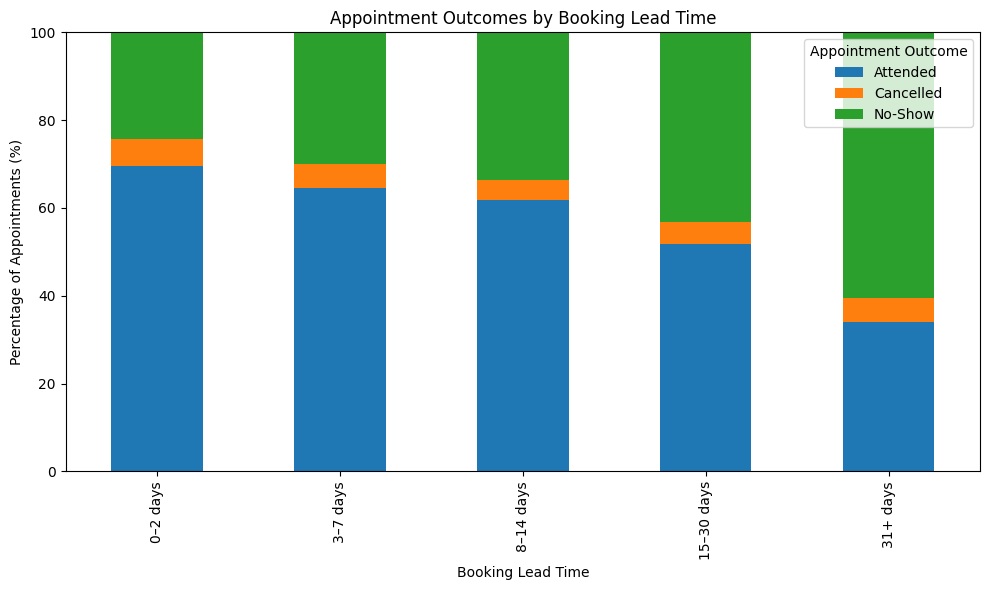

In [49]:
outcome_by_lead_time.plot(
    x="booking_lead_group_test",
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Appointment Outcomes by Booking Lead Time")
plt.xlabel("Booking Lead Time")
plt.ylabel("Percentage of Appointments (%)")
plt.legend(title="Appointment Outcome")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**Validation Result:** The appointment outcome distribution by booking lead time was independently reproduced. Outcome proportions and lead-time group ordering matched the Week 6 analysis, with no inconsistencies identified.

**Refinement:** No substantive correction was required.

**Status:** Pass

### 6.2 No-Show Rate by Previous No-Shows and Booking Lead Time

In [47]:
heatmap_validation = (
    df.pivot_table(
        index="previous_no_shows",
        columns="booking_lead_group_test",
        values="appointment_outcome",
        aggfunc=lambda x: (x == "No-Show").mean() * 100,
        observed=True
    )
)

heatmap_validation

booking_lead_group_test,0–2 days,3–7 days,8–14 days,15–30 days,31+ days
previous_no_shows,,,,,
0,17.808219,24.336283,31.648936,38.401048,55.177305
1,30.434783,34.710744,31.847134,46.778043,66.368286
2,46.153846,51.351351,45.762712,52.800000,71.204188
3,0.000000,27.272727,50.000000,85.714286,80.000000
4,NaN,0.000000,100.000000,60.000000,80.000000
5,NaN,NaN,100.000000,NaN,100.000000


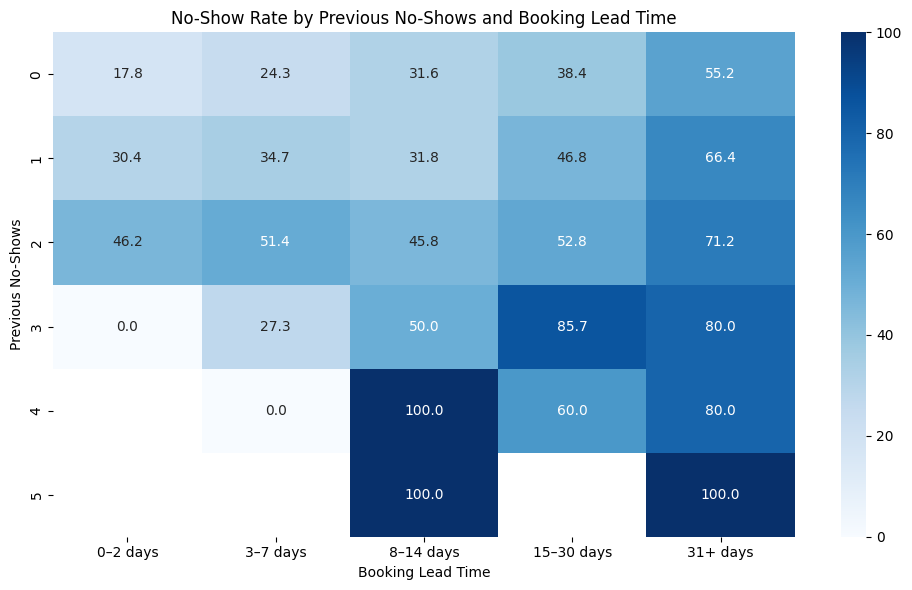

In [51]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_validation,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("No-Show Rate by Previous No-Shows and Booking Lead Time")
plt.xlabel("Booking Lead Time")
plt.ylabel("Previous No-Shows")
plt.tight_layout()
plt.show()

**Validation Result:** The no-show rate heatmap was independently reproduced from the underlying data. The observed pattern across previous no-show history and booking lead time was consistent with the Week 6 analysis, including the higher observed no-show rates among longer booking lead times and repeated no-show groups.

**Refinement:** No numerical correction was required. Interpretation remains focused on observed associations, particularly where subgroup sizes are smaller.

**Status:** Pass

## 7. Cross-Track Validation

### 7.1 Data Analytics → Data Science
The validated Week 7 Analytics findings were handed over to the Data Science track for independent modelling validation. Data Science tested whether the observed relationships were reflected in predictive modelling and whether any modelling assumptions or feature choices required refinement.

#### Cross-Track Validation Record

| Component Tested         | Testing Objective                                                                            | Actual Result                                                                                                                    | Action / Refinement                                                                    | Retest Result                                                                 |
| ------------------------ | -------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------- |
| Booking lead time        | Determine whether the observed increasing no-show rate is reflected in the model             | Continuous `booking_lead_days` carried strong predictive signal, with an additional jump for 31+ days                            | Remove redundant `booking_lead_group` from predictive model                            | ROC-AUC changed from 0.6843 to 0.6845; no meaningful performance loss         |
| Previous no-show history | Check whether feature relationships are correctly represented                                | Multicollinearity between previous-history variables caused `previous_no_show_rate` to receive an incorrect negative coefficient | Remove `previous_appointments` and `previous_no_shows`; retain `previous_no_show_rate` | Coefficient changed from -0.106 to +0.195, aligning with Analytics finding    |
| Higher-risk segments     | Test whether compounding risk requires an explicit interaction term                          | Interaction provided negligible additional predictive value                                                                      | Retain simpler additive model                                                          | High-risk predictions remained almost unchanged; Brier score 0.2093 vs 0.2094 |
| Reminder coverage        | Test whether reminder coverage confounds the lead-time relationship                          | Lead-time coefficient changed only 0.0111 when reminder features were removed                                                    | No change required                                                                     | Lead-time signal remained stable                                              |
| Reminder effectiveness   | Determine whether reminder variables provide predictive information beyond lead time/history | Reminder block added significant predictive information (LR = 11.53, df = 3, p = 0.0092)                                         | Retain reminder features, while preserving non-causal interpretation                   | Reminder variables remained statistically informative                         |


#### Cross-Track Validation Result

The Data Science validation independently supported the major Analytics findings while identifying one substantive modelling issue. The Week 6 candidate model included `previous_appointments`, `previous_no_shows`, and the derived `previous_no_show_rate` simultaneously. Their multicollinearity caused the rate variable to receive an incorrect negative coefficient.

Removing the collinear raw-count predictors and retaining `previous_no_show_rate` corrected the coefficient direction from -0.106 to +0.195, while model performance remained within the established validation range.

The validation also showed that `booking_lead_group` is useful for stakeholder-facing Analytics reporting but redundant as a predictive feature when continuous `booking_lead_days` is already included. An explicit interaction between previous no-show rate and booking lead time also provided negligible additional predictive value.

Reminder variables added statistically significant predictive information beyond lead time and history, but this does not establish a causal effect of reminders on attendance.

**Validated Improvement:** The cross-track exercise resulted in a refined predictive feature set and corrected an incorrect feature interpretation from the Week 6 Data Science model.

The corrected candidate model uses:

`booking_lead_days` + `previous_no_show_rate` + `is_new_patient` + `reminder_sent` + `reminder_channel`

This improves the consistency between the Analytics findings and the Data Science model while avoiding unnecessary model complexity.

## 8. Issues and Refinements

Week 7 testing identified one substantive modelling issue and several opportunities for refinement.

### 8.1 Multicollinearity in the Data Science Model

The Week 6 candidate model included `previous_appointments`, `previous_no_shows`, and `previous_no_show_rate`. Because the rate is derived from the two raw counts, these variables introduced moderate-to-high multicollinearity (VIF 3.55–4.50).

This caused the `previous_no_show_rate` coefficient to become negative (-0.106), contradicting the independently validated Analytics finding.

**Refinement:** The raw count variables were removed from the predictive model, while `previous_no_show_rate` was retained. The coefficient became positive (+0.195), restoring the expected direction.

### 8.2 Redundant Booking Lead-Time Feature

`booking_lead_group` added negligible predictive value once continuous `booking_lead_days` was included. Removing the grouped feature changed ROC-AUC by only 0.0002.

**Refinement:** Retain continuous `booking_lead_days` for modelling while continuing to use the grouped version for Analytics reporting and stakeholder communication.

### 8.3 Interaction Complexity

An explicit interaction between previous no-show rate and booking lead time produced negligible improvement.

**Refinement:** Retain the simpler additive model rather than introducing unnecessary interaction complexity.

### 8.4 Reminder Interpretation

Reminder variables added statistically significant predictive information, but the modelling evidence remains observational.

**Refinement:** Continue to describe reminder findings as associations/predictive signals rather than causal effects.

## 9. Retesting 

Following the identified refinements, the affected components were retested using the same validation framework.

### 9.1 Booking Lead-Time Feature

Removing `booking_lead_group` while retaining continuous `booking_lead_days` resulted in:

- With grouped feature: ROC-AUC = 0.6843
- Without grouped feature: ROC-AUC = 0.6845
- Difference: +0.0002

**Result:** Pass. The grouped feature can be removed from the predictive model without meaningful performance loss.

### 9.2 Previous No-Show Features

After removing the collinear raw-count variables:

- `previous_no_show_rate` coefficient changed from **-0.106** to **+0.195**
- Refined model ROC-AUC = **0.6843**

The coefficient direction now agrees with the independently validated Analytics finding.

**Result:** Pass. The modelling issue was corrected and the finding remained supported.

### 9.3 Interaction Term

The interaction model produced:

- Additive model Brier score: **0.2093**
- Interaction model Brier score: **0.2094**
- Overall ROC-AUC: **0.6843 → 0.6850**

The negligible change did not justify additional model complexity.

**Result:** Pass. The simpler additive model was retained.

### 9.4 Reminder Features

The likelihood-ratio test showed:

- LR statistic = **11.53**
- df = **3**
- p = **0.0092**

**Result:** Pass. Reminder variables provide additional predictive information beyond lead time and patient history, while the non-causal limitation remains.

## 9. Validation Summary

Week 7 testing independently reproduced the four HealthConnect KPIs, the major analytical findings from Week 6, and the two advanced-analysis visualisations. No numerical inconsistencies were identified in the Analytics outputs.

The cross-track validation with Data Science provided additional model-based evidence for the relationships identified by Analytics. Booking lead time and previous no-show history remained important signals, while reminder variables provided additional predictive information.

The most important issue identified was multicollinearity in the Week 6 Data Science feature set. Removing the related raw-count variables corrected the direction of the previous no-show rate coefficient without materially changing model performance.

Further testing showed that grouped booking lead time was unnecessary for predictive modelling when continuous lead time was retained, while an explicit interaction between previous no-show history and lead time provided negligible additional value.

The final validated position is therefore:

- Analytics findings are reproducible against the underlying data.
- Booking lead time and previous no-show history remain important indicators of no-show behaviour.
- Higher-risk combinations are supported by the observed data but should not be interpreted as individual-level predictive classifications.
- Reminder variables contain additional predictive signal, but their effect remains non-causal in this observational dataset.
- The predictive model can be simplified without meaningful loss of performance.
- The corrected Data Science feature set should replace the Week 6 candidate feature configuration.

No unresolved numerical or analytical inconsistencies remain in the tested Analytics outputs. Remaining limitations include the observational nature of the dataset, the synthetic/anonymised data context, and the inability to establish causal effects of reminders without controlled intervention.